# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Ana Sittah Rosyidah, S.ST.
- Email: ana5210@guru.smk.belajar.id

- Id Dicoding:https://www.dicoding.com/users/ana_sittah_rosyidah/academies

## Persiapan

### Menyiapkan library yang dibutuhkan

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
import sqlalchemy
import sklearn
import joblib

### Menyiapkan data yang akan diguankan

## Data Understanding

*   Memprediksi apakah karyawan akan keluar (Attrition)
*   Mengidentifikasi faktor penyebab attrition

####Konstan / tidak berguna:
*   EmployeeCount (selalu 1)
*   Over18 (selalu "Y")
*   StandardHours (selalu 80)

#### fitur penting:
*   Target (label):
    - Attrition → (1 = keluar, kosong/0 = tidak keluar)
*   Numerik:
    - Age, DailyRate, MonthlyIncome, DistanceFromHome
    - TotalWorkingYears, YearsAtCompany, dll
*   Kategorikal:
    - BusinessTravel, Department, Gender, JobRole
    - MaritalStatus, OverTime, dll

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/a590-Belajar-Penerapan-Data-Science-a590_proyek_pertama/a590_proyek_pertama/employee/employee_data.csv")

In [ ]:
df.head(10)

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2
5,6,29,NaN,Travel_Rarely,352,Human Resources,6,1,Medical,1,...,4,80,0,1,3,3,1,0,0,0
6,7,40,0.0,Travel_Rarely,1124,Sales,1,2,Medical,1,...,3,80,3,6,2,2,4,3,0,2
7,8,55,1.0,Travel_Rarely,725,Research & Development,2,3,Medical,1,...,4,80,1,24,2,3,5,2,1,4
8,9,36,0.0,Travel_Frequently,635,Research & Development,18,1,Medical,1,...,1,80,0,8,2,3,8,1,1,7
9,10,32,0.0,Travel_Rarely,1018,Research & Development,3,2,Life Sciences,1,...,4,80,0,10,6,3,7,7,7,7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

In [ ]:
df.describe()

,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1058.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,36.923810,0.169187,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.375094,403.509100,8.106864,1.024165,0.0,1.093082,20.329428,0.711561,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.750000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1470.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## Data Preparation / Preprocessing

In [ ]:
print("--- Jumlah NaN per Kolom ---")
print(df.isnull().sum())

--- Jumlah NaN per Kolom ---
EmployeeId                    0
Age                           0
Attrition                   412
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome              0
Education                     0
EducationField                0
EmployeeCount                 0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction               0
MaritalStatus                 0
MonthlyIncome                 0
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours                 0
StockOptionLevel              0
TotalWorkingYears             0
TrainingTimesLastYear         0
WorkLifeBal

In [ ]:
# 1. Hapus kolom konstan
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours']
df.drop(columns=cols_to_drop, axis=1, inplace=True, errors='ignore')

# 2. Tangani Data Kosong (NaN)
# Di sini kita gunakan dropna agar data benar-benar valid, atau ganti dengan implemenasi Opsi B di atas
df.dropna(inplace=True)


#Lihat 5 data teratas
print(df.head())

#Lihat struktur kolom
print(df.columns)

#Lihat ukuran data
print(df.shape)

# 3. Simpan ke CSV
save_path = '/content/drive/MyDrive/Colab Notebooks/a590-Belajar-Penerapan-Data-Science-a590_proyek_pertama/a590_proyek_pertama/dashboard/employee_data_cleaned.csv'
df.to_csv(save_path, index=False)

print(f"✅ Data bersih (Tanpa NaN) disimpan ke: {save_path}")
print(f"Ukuran Akhir Data: {df.shape}")

   EmployeeId  Age  Attrition     BusinessTravel  DailyRate  \
1           2   37        1.0      Travel_Rarely       1141   
2           3   51        1.0      Travel_Rarely       1323   
3           4   42        0.0  Travel_Frequently        555   
6           7   40        0.0      Travel_Rarely       1124   
7           8   55        1.0      Travel_Rarely        725   

               Department  DistanceFromHome  Education EducationField  \
1  Research & Development                11          2        Medical   
2  Research & Development                 4          4  Life Sciences   
3                   Sales                26          3      Marketing   
6                   Sales                 1          2        Medical   
7  Research & Development                 2          3        Medical   

   EnvironmentSatisfaction  ... PerformanceRating  RelationshipSatisfaction  \
1                        1  ...                 3                         1   
2                       

In [ ]:
# 2. Target Cleaning & Encoding
# # Hapus data tanpa label
# df = df.dropna(subset=['Attrition'])

# # Pastikan tipe integer
# df['Attrition'] = df['Attrition'].astype(int)

# # Cek hasil
# print(df['Attrition'].value_counts())
# print(df['Attrition'].unique())
# df['Attrition'] = df['Attrition'].replace({
#     'Yes': 1, 'No': 0,
#     'yes': 1, 'no': 0,
#     1: 1, 0: 0
# })

# df['Attrition'] = df['Attrition'].fillna(0)

# Hapus baris di mana target (Attrition) kosong
df = df.dropna(subset=['Attrition'])

# Mapping label string ke angka (jika data masih berupa 'Yes'/'No')
if df['Attrition'].dtype == 'object':
    df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0, 'yes': 1, 'no': 0})

# Pastikan tipe data integer dan isi sisa NaN (jika ada) dengan 0
df['Attrition'] = df['Attrition'].fillna(0).astype(int)

print(df[['Attrition']].head())
print(df['Attrition'].unique())
print(df['Attrition'].unique())
print(df['Attrition'].isnull().sum())
print(df['Attrition'].isnull().sum())
print(df[['Attrition']].head(10))


# Cek
print(df['Attrition'].value_counts())
print(df['Attrition'].unique())

   Attrition
1          1
2          1
3          0
6          0
7          1
[1 0]
[1 0]
0
0
    Attrition
1           1
2           1
3           0
6           0
7           1
8           0
9           0
10          0
11          1
13          0
Attrition
0    879
1    179
Name: count, dtype: int64
[1 0]


In [ ]:
# 3. Encoding fitur
# df_encoded = pd.get_dummies(df.drop('Attrition', axis=1), drop_first=True)
# df_encoded['Attrition'] = df['Attrition']

# Mengubah variabel kategori menjadi dummy variables
# drop_first=True untuk menghindari dummy variable trap
X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_encoded = pd.get_dummies(X, drop_first=True)


In [ ]:
# 4. Train-Test Split
from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# 5. (Opsional) Scaling
from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)
scaler = StandardScaler()
# Fit hanya pada data training untuk menghindari data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# --- 6. Output Final ---
print("### Data Summary ###")
print(f"Bentuk awal data: {df.shape}")
print(f"Distribusi Target:\n{y.value_counts()}")
print("-" * 20)
print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape : {X_test_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape : {y_test.shape}")

### Data Summary ###
Bentuk awal data: (1058, 32)
Distribusi Target:
Attrition
0    879
1    179
Name: count, dtype: int64
--------------------
X_train shape: (846, 45)
X_test shape : (212, 45)
y_train shape: (846,)
y_test shape : (212,)


In [ ]:
# evaluasi manual (EDA)
import pandas as pd

# 1. LOAD DATA (Pastikan baris ini dijalankan)
df_raw = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/a590-Belajar-Penerapan-Data-Science-a590_proyek_pertama/a590_proyek_pertama/dashboard/employee_data_cleaned.csv')

# 2. FUNGSI EVALUASI
def attrition_rate(df, column):
    return (df.groupby(column)['Attrition'].mean() * 100).round(2).sort_values(ascending=False)

# 3. PENGELOMPOKAN (Binned Data) untuk Age, Income, dan Career Stage
# Agar evaluasi lebih bermakna, kita bagi angka kontinu menjadi kelompok
df_raw['Age_Group'] = pd.cut(df_raw['Age'], bins=[0, 30, 40, 50, 100], labels=['<30', '30-40', '40-50', '>50'])
df_raw['Income_Group'] = pd.qcut(df_raw['MonthlyIncome'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
df_raw['Career_Stage'] = pd.cut(df_raw['TotalWorkingYears'], bins=[0, 5, 10, 20, 100], labels=['Entry', 'Mid', 'Senior', 'Veteran'])

# 4. TAMPILKAN HASIL EVALUASI
print("=== ANALISIS ATTRITION RATE PER KATEGORI (%) ===")
print(f"\n1. Berdasarkan Usia (Age):\n{attrition_rate(df_raw, 'Age_Group')}")
print(f"\n2. Berdasarkan Gender:\n{attrition_rate(df_raw, 'Gender')}")
print(f"\n3. Berdasarkan Departemen:\n{attrition_rate(df_raw, 'Department')}")
print(f"\n4. Berdasarkan Job Role:\n{attrition_rate(df_raw, 'JobRole')}")
print(f"\n5. Berdasarkan Lembur (Overtime):\n{attrition_rate(df_raw, 'OverTime')}")
print(f"\n6. Berdasarkan Pendapatan (Income):\n{attrition_rate(df_raw, 'Income_Group')}")
print(f"\n7. Berdasarkan Tahapan Karier (Career Stage):\n{attrition_rate(df_raw, 'Career_Stage')}")

=== ANALISIS ATTRITION RATE PER KATEGORI (%) ===

1. Berdasarkan Usia (Age):
Age_Group
<30      26.76
30-40    14.75
>50      11.86
40-50    11.35
Name: Attrition, dtype: float64

2. Berdasarkan Gender:
Gender
Male      17.42
Female    16.21
Name: Attrition, dtype: float64

3. Berdasarkan Departemen:
Department
Sales                     20.69
Human Resources           15.79
Research & Development    15.26
Name: Attrition, dtype: float64

4. Berdasarkan Job Role:
JobRole
Sales Representative         43.10
Laboratory Technician        26.06
Human Resources              20.00
Research Scientist           17.76
Sales Executive              16.81
Healthcare Representative     9.09
Manufacturing Director        6.54
Manager                       6.33
Research Director             3.23
Name: Attrition, dtype: float64

5. Berdasarkan Lembur (Overtime):
OverTime
Yes    31.92
No     10.79
Name: Attrition, dtype: float64

6. Berdasarkan Pendapatan (Income):
Income_Group
Low          29.06
Medium 

/tmp/ipykernel_5047/3454410306.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return (df.groupby(column)['Attrition'].mean() * 100).round(2).sort_values(ascending=False)
/tmp/ipykernel_5047/3454410306.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return (df.groupby(column)['Attrition'].mean() * 100).round(2).sort_values(ascending=False)


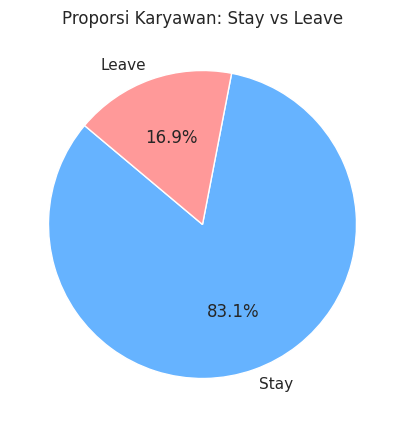

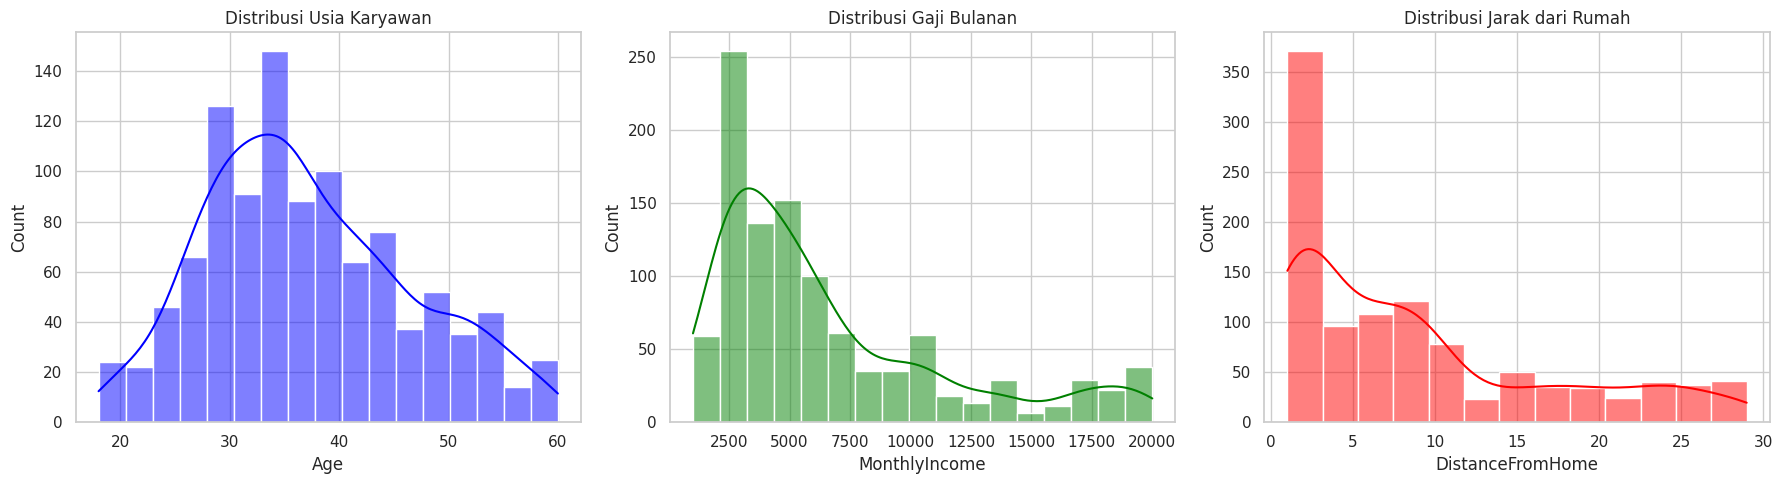

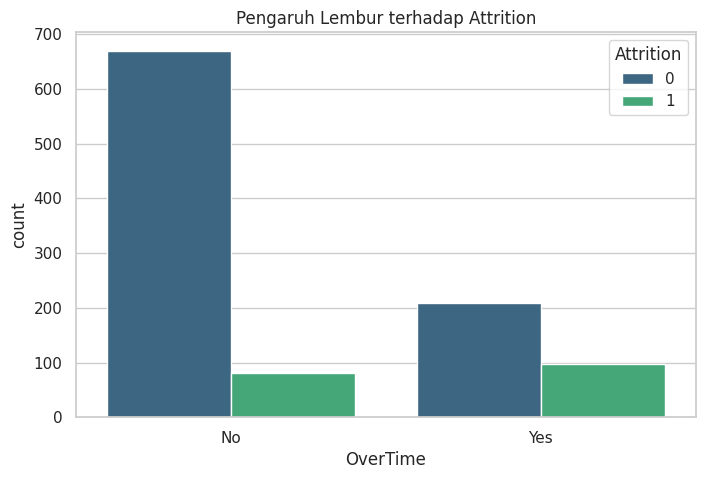

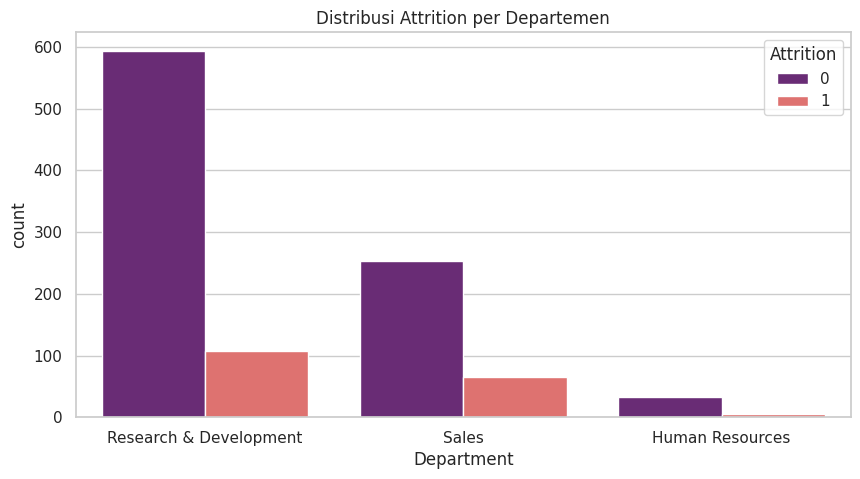

/tmp/ipykernel_5047/1411150217.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', ax=axes[0], palette='Set2')
/tmp/ipykernel_5047/1411150217.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='Age', ax=axes[1], palette='Set1')


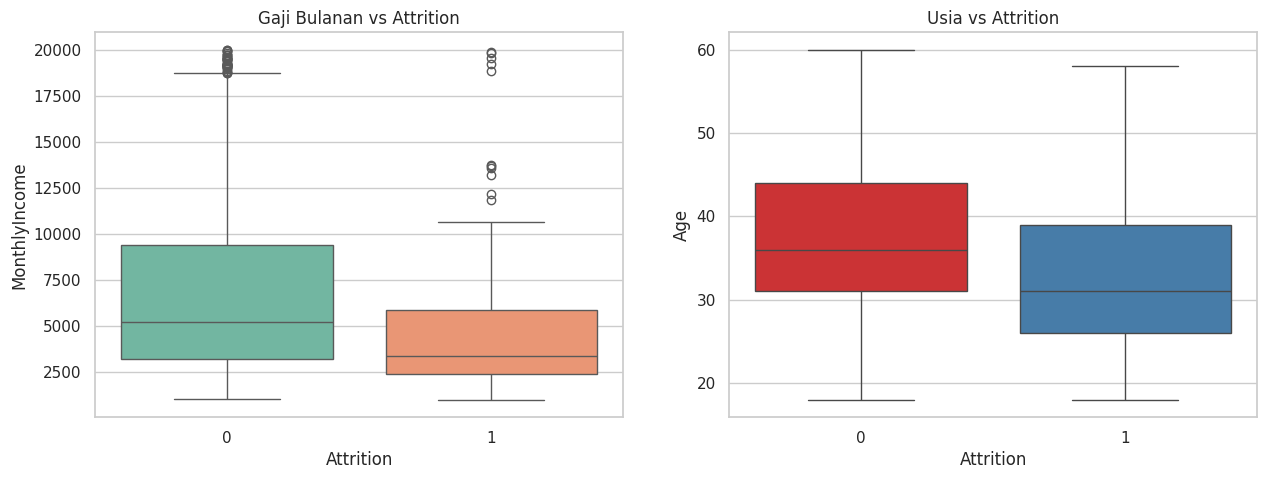

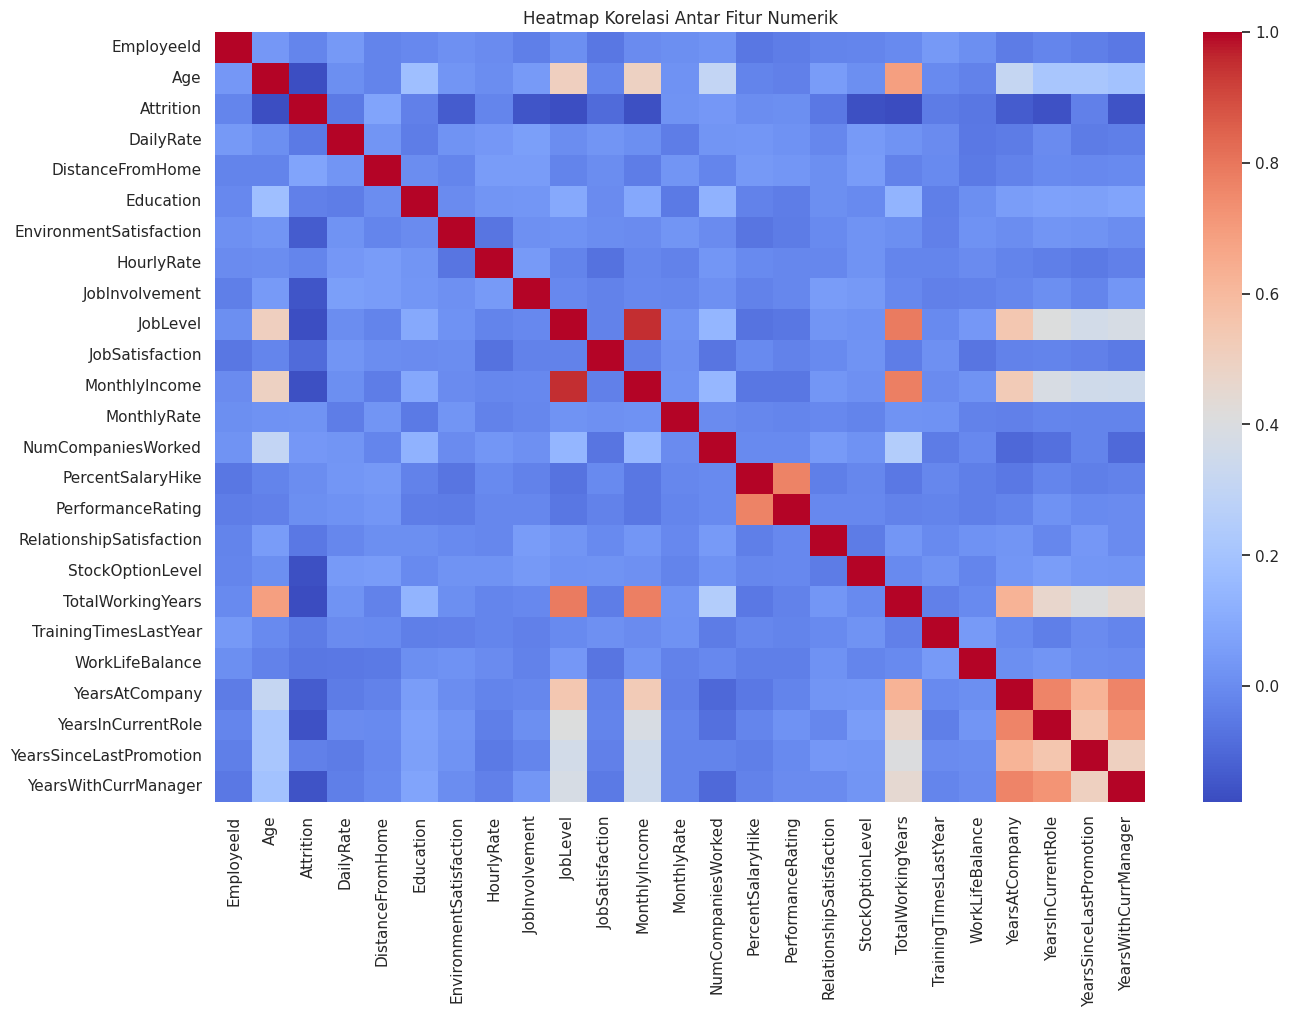

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Atur tema visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### 1. Univariate Analysis (Analisis Satu Variabel)

# A. Distribusi Target (Attrition)
plt.figure(figsize=(7, 5))
attrition_counts = df['Attrition'].value_counts()
plt.pie(attrition_counts, labels=['Stay', 'Leave'], autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999'])
plt.title('Proporsi Karyawan: Stay vs Leave')
plt.show()
# Insight: Terjadi ketidakseimbangan data (Imbalance), di mana mayoritas karyawan tetap tinggal.

# B. Distribusi Numerik Utama
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Age'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribusi Usia Karyawan')

sns.histplot(df['MonthlyIncome'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribusi Gaji Bulanan')

sns.histplot(df['DistanceFromHome'], kde=True, ax=axes[2], color='red')
axes[2].set_title('Distribusi Jarak dari Rumah')

plt.tight_layout()
plt.show()

### 2. Multivariate/Bivariate Analysis (Hubungan Fitur vs Attrition)

# A. Attrition berdasarkan Lembur (OverTime)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='OverTime', hue='Attrition', palette='viridis')
plt.title('Pengaruh Lembur terhadap Attrition')
plt.show()
# Insight: Karyawan yang sering lembur memiliki kecenderungan keluar lebih tinggi secara proporsional.

# B. Attrition berdasarkan Departemen
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Department', hue='Attrition', palette='magma')
plt.title('Distribusi Attrition per Departemen')
plt.show()

# C. Analisis Gaji dan Usia terhadap Attrition (Boxplot)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', ax=axes[0], palette='Set2')
axes[0].set_title('Gaji Bulanan vs Attrition')

sns.boxplot(data=df, x='Attrition', y='Age', ax=axes[1], palette='Set1')
axes[1].set_title('Usia vs Attrition')

plt.show()
# Insight: Karyawan yang keluar cenderung memiliki gaji rata-rata yang lebih rendah dan usia yang lebih muda.

### 3. Analisis Korelasi (Correlation Heatmap)

# Memilih kolom numerik saja untuk korelasi
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(15, 10))
sns.heatmap(df[numerical_cols].corr(), annot=False, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Antar Fitur Numerik')
plt.show()

## Modeling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

# A. Splitting (Gunakan stratify agar distribusi target tetap adil)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# B. Scaling (Mencegah fitur dengan angka besar mendominasi fitur kecil)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# C. SMOTE (Menyeimbangkan jumlah karyawan yang 'Stay' dan 'Leave')
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# D. Pelatihan Model (Konfigurasi terbaik)
# n_estimators=200 memberikan stabilitas lebih baik daripada 100
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10, # Mencegah overfitting
    random_state=42,
    class_weight='balanced' # Pengamanan tambahan untuk imbalance data
)

model.fit(X_train_res, y_train_res)
print("✅ Modeling selesai: Model telah dilatih dengan data yang diskalakan dan diseimbangkan.")

✅ Modeling selesai: Model telah dilatih dengan data yang diskalakan dan diseimbangkan.


## Evaluation


📋 LAPORAN EVALUASI MODEL
              precision    recall  f1-score   support

           0       0.88      0.95      0.92       176
           1       0.64      0.39      0.48        36

    accuracy                           0.86       212
   macro avg       0.76      0.67      0.70       212
weighted avg       0.84      0.86      0.84       212

Total Akurasi: 85.85%


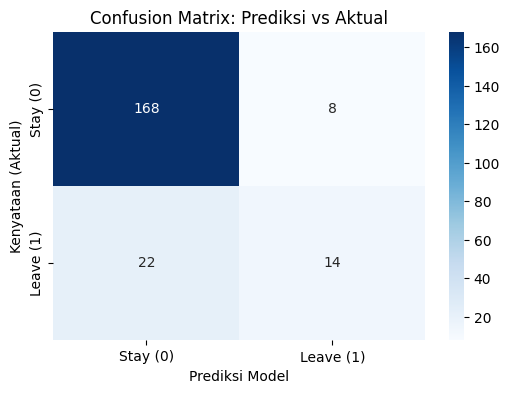

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# A. Prediksi
y_pred = model.predict(X_test_scaled)

# B. Laporan Metrik
print("\n" + "="*40)
print("📋 LAPORAN EVALUASI MODEL")
print("="*40)
print(classification_report(y_test, y_pred))
print(f"Total Akurasi: {accuracy_score(y_test, y_pred):.2%}")

# C. Visualisasi Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay (0)', 'Leave (1)'],
            yticklabels=['Stay (0)', 'Leave (1)'])
plt.title('Confusion Matrix: Prediksi vs Aktual')
plt.xlabel('Prediksi Model')
plt.ylabel('Kenyataan (Aktual)')
plt.show()

In [ ]:
# Gunakan data X_test asli (bukan yang scaled) agar angkanya mudah dibaca (misal: Age 37 thn)
X_test_df = X_test.copy()
X_test_df['Actual'] = y_test.values
X_test_df['Predicted'] = y_pred

# Filter kelompok
false_negative = X_test_df[(X_test_df['Actual'] == 1) & (X_test_df['Predicted'] == 0)]
true_positive = X_test_df[(X_test_df['Actual'] == 1) & (X_test_df['Predicted'] == 1)]


In [ ]:
# --- ANALISIS WAWASAN BISNIS: MENGAPA KARYAWAN KELUAR? ---

# 1. Identifikasi Karakteristik Karyawan dan Pembulatan
comparison = pd.DataFrame({
    'Karakteristik Attrition Tersembunyi (FN)': false_negative.mean(),
    'Karakteristik Attrition Terdeteksi (TP)': true_positive.mean()
})

# 2. Hitung Selisih
comparison['Tingkat Kontras'] = comparison['Karakteristik Attrition Tersembunyi (FN)'] - comparison['Karakteristik Attrition Terdeteksi (TP)']

# 3. Tampilkan dengan pembulatan (misal: 2 angka di belakang koma)
print("=== WAWASAN UTAMA: FAKTOR PENDORONG KARYAWAN KELUAR ===")

# Menambahkan .round(2) sebelum head(10)
hasil_akhir = comparison.sort_values(by='Tingkat Kontras', ascending=False).head(10).round(2)

display(hasil_akhir)

=== WAWASAN UTAMA: FAKTOR PENDORONG KARYAWAN KELUAR ===


,Karakteristik Attrition Tersembunyi (FN),Karakteristik Attrition Terdeteksi (TP),Tingkat Kontras
MonthlyIncome,5560.73,2489.29,3071.44
DailyRate,914.68,698.71,215.97
Age,37.05,29.00,8.05
TotalWorkingYears,10.95,3.86,7.10
DistanceFromHome,12.45,7.00,5.45
YearsAtCompany,4.68,1.79,2.90
HourlyRate,64.32,61.57,2.75
YearsInCurrentRole,3.50,1.00,2.50
YearsSinceLastPromotion,2.09,0.50,1.59
YearsWithCurrManager,2.45,1.00,1.45


# 📊 Analisis Wawasan Bisnis: Mengapa Karyawan Mengundurkan Diri?

Tabel di bawah ini membandingkan karakteristik antara karyawan yang **gagal terdeteksi (Tersembunyi)** dan karyawan yang **berhasil terdeteksi (Terdeteksi)** oleh model prediksi.

| Fitur Utama | Profil Tersembunyi (Senior) | Profil Terdeteksi (Junior) | Tingkat Kontras | Insight Strategis |
| :--- | :---: | :---: | :---: | :--- |
| **Gaji Bulanan** | **$5.560** | $2.489 | **+$3.071** | Gaji tinggi adalah *blind spot* utama; kompensasi finansial bukan penahan bagi kelompok senior. |
| **Usia** | **37 Tahun** | 29 Tahun | **+8 Tahun** | Model cenderung fokus pada profil muda, sehingga mengabaikan risiko pada karyawan yang lebih mapan. |
| **Jarak Rumah** | **12,4 Km** | 7,0 Km | **+5,4 Km** | Jarak tempuh yang jauh menjadi pemicu kelelahan (*burnout*) laten pada kelompok senior. |
| **Pengalaman** | **11 Tahun** | 4 Tahun | **+7 Tahun** | Karyawan dengan pengalaman tinggi memiliki kepercayaan diri lebih besar untuk mencari peluang baru. |
| **Kepuasan** | **2,50** | 2,14 | **+0,36** | Model gagal mendeteksi karyawan dengan tingkat kepuasan "moderat" (terlihat stabil namun sebenarnya rentan). |

---

### 🔍 Ringkasan Temuan Utama: "Risiko Tersembunyi"

Berdasarkan data di atas, kita dapat mengidentifikasi dua profil pengunduran diri (*attrition*) yang sangat berbeda:

* **1. Attrition Profil Junior:**
    Kelompok ini terdiri atas karyawan muda dengan gaji tingkat awal (*entry-level*) dan masa kerja yang singkat. Pola pergerakan mereka terekam dengan jelas oleh data historis, sehingga mudah diprediksi oleh model AI.

* **2. Attrition Profil Senior:**
    Inilah risiko nyata bagi perusahaan. Mereka adalah karyawan senior dengan gaji mapan dan produktivitas tinggi. Kelompok ini cenderung mengundurkan diri bukan karena faktor finansial, melainkan diduga karena **stagnansi karier** dan **beban perjalanan** yang jauh.

---

### 💡 Rekomendasi Aksi untuk Manajer SDM (HR Manager)

1.  **Fleksibilitas Kerja:** Bagi kelompok senior yang memiliki jarak rumah jauh (>12 km), pertimbangkan kebijakan kerja dikantor dan dirumah (*hybrid work*) untuk mengurangi faktor kelelahan fisik.
2.  **Pengayaan Karier (*Career Enrichment*):** Jangan hanya mengandalkan kenaikan gaji. Karyawan senior membutuhkan tantangan baru atau rotasi posisi untuk mengatasi kejenuhan kerja.
3.  **Pendekatan Proaktif (Proactive Engagement):** Tetap Lakukan wawancara *(stay interview)* khusus bagi karyawan dengan masa kerja 4—5 tahun (titik jenuh kelompok senior), meskipun skor kepuasan mereka terlihat berada di level rata-rata.

> **📌 Kesimpulan Akhir (Proactive Engagement):**
> Perusahaan menghadapi risiko tinggi kehilangan aset manusia yang berharga (*High-Value Employees*). Mereka sering dianggap loyal karena posisi dan kemapanannya, namun data membuktikan bahwa mereka adalah kelompok yang paling sering luput dari sistem deteksi dini saat akan mengundurkan diri.